In [2]:
import pandas as pd
import ast
import numpy as np
import matplotlib.pyplot as plt
import os
PROJECT_ROOT = "/Users/maria/springboard/Project"
os.chdir(PROJECT_ROOT)


#read data
#upload news and price data
news = pd.read_csv('data/news/all_news.csv', date_format='pubDate')
price = pd.read_csv('data/all_zec.csv')
print('before dedup', news.shape, price.shape)
#normalize timestamps
price['timestamp'] = pd.to_datetime(price['timestamp'], utc=True)
news['pubDate'] = pd.to_datetime(news['pubDate'], utc=True)
news['fetched_at'] = pd.to_datetime(news['fetched_at'], utc=True)
news = news.drop_duplicates(subset='article_id')
news = news.sort_values(by = 'pubDate').reset_index(drop=True)
price = price.drop_duplicates(subset='timestamp')
price = price.set_index('timestamp').sort_index()
print('after_dedup (news df already was dedupped)', news.shape, price.shape)

before dedup (7857, 23) (28644, 4)
after_dedup (news df already was dedupped) (7857, 23) (23349, 3)


In [ ]:
#tfidf scores
from sklearn.feature_extraction.text import TfidfVectorizer

# --- TF-IDF for title ---
tfidf_title = TfidfVectorizer(
    max_features=300,      # keep small for interpretability
    ngram_range=(1, 2),    # unigrams + bigrams
    stop_words="english",
    min_df=5               # ignore ultra-rare words
)

X_title = tfidf_title.fit_transform(news["title"].fillna(""))

# --- TF-IDF for description ---
tfidf_desc = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=10
)

X_desc = tfidf_desc.fit_transform(news["description"].fillna(""))


In [ ]:
print(news.iloc[0]['title'])
#see content
i=0
row = X_title[i]
tf_idf_df = pd.DataFrame(row.toarray().T, 
                         index = tfidf_title.get_feature_names_out(),
                         columns=["tfidf"])
tf_idf_df[tf_idf_df['tfidf']>0]

Top Crypto Losers: Zcash, Starknet, and Ethena lead losses amid bearish pressure


,tfidf
amid,0.343639
bearish,0.462791
crypto,0.179117
lead,0.426200
losers,0.475271
pressure,0.447073
zcash,0.168079


In [ ]:
#feature prep of OHE
#sentiment: we have some missing values in sentiment. I will assign neutral
news.loc[news['sentiment']=='ONLY AVAILABLE IN PROFESSIONAL AND CORPORATE PLANS','sentiment']='neutral'
#creator: assing unknown when creator is na
news.loc[news['creator'].isna(),'creator']='UNKNOWN'
#sources: remove low freq sources.tot = 183 lets remove sources that are only showing up 2 or less: 62 sources
min_count = 3
source_counts = news['source_id'].value_counts()
rare_sources = source_counts[source_counts< min_count].index
news['source_id_clean'] = news['source_id'].where(~news['source_id'].isin(rare_sources), other = 'OTHER')

#Not using: assign frequency to variables instead of OHE
for col in ["source_id", "creator",'sentiment']:
    freq = news[col].value_counts(normalize=True)
    news[col + "_freq"] = news[col].map(freq)

In [ ]:
#one hot encode function
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(
    drop="first",        # avoid perfect multicollinearity
    sparse_output=True,
    handle_unknown="ignore"
)
X_features_ohe = ohe.fit_transform(news[['source_id_clean','sentiment']])

In [ ]:
X_numeric = news[['title_word_count','word_count', 'num_coins_mentioned']].fillna(0).values
X= hstack([X_numeric, X_features_ohe])
y= news['high_impact']

In [ ]:
#split train test
split = int(len(news) * 0.8)

X_train, X_test = X.tocsr()[:split], X.tocsr()[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    class_weight="balanced",
    C=1.0
)

model.fit(X_train, y_train)


,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
feature_names = (
    ["title_word_count", "description_word_count", 'num_coins_mentioned']
    + list(ohe.get_feature_names_out(["source_id_clean", 'sentiment']))
)

coef = pd.Series(model.coef_[0], index=feature_names)


In [ ]:
#source driver impact
coef.filter(like='source_').sort_values(ascending= False)

source_id_clean_bravenewcoin       1.863273
source_id_clean_fool               1.026896
source_id_clean_airdropalert       1.018413
source_id_clean_cryptodaily        0.879127
source_id_clean_binance            0.873806
                                     ...   
source_id_clean_thebitjournal     -0.975274
source_id_clean_watcherguru       -1.034905
source_id_clean_dlnews            -1.079043
source_id_clean_thecoinrise       -1.232744
source_id_clean_livebitcoinnews   -1.320429
Length: 121, dtype: float64

In [ ]:
#others driving impact
coef[~coef.index.str.contains('source')]

title_word_count          0.004592
description_word_count    0.000823
num_coins_mentioned       0.128637
sentiment_neutral        -0.452587
sentiment_positive       -0.490490
sentiment_nan            -0.269755
dtype: float64

In [ ]:
bot_sources = (
    coef
    .filter(like="source_id")
    .sort_values(ascending=True)
    .head(10)
)
top_sources = (
    coef
    .filter(like="source_id")
    .sort_values(ascending=False)
    .head(10)
)
driving_sources = pd.concat([bot_sources,top_sources]).sort_values()

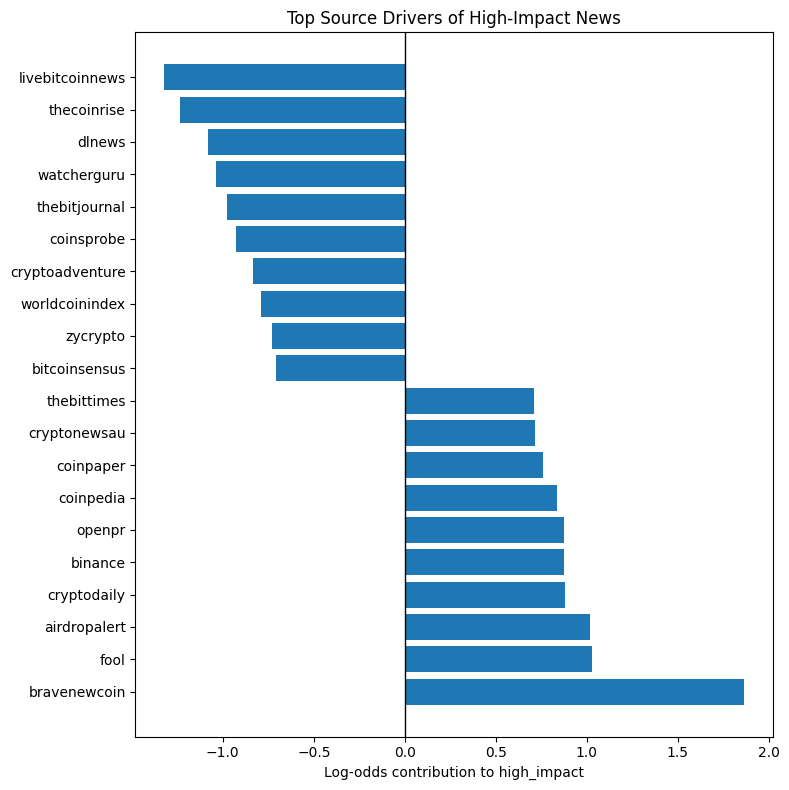

In [ ]:

# clean up labels
labels = driving_sources.index.str.replace("source_id_clean_", "", regex=False)

plt.figure(figsize=(8, 8))
plt.barh(labels, driving_sources.values)
plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Log-odds contribution to high_impact")
plt.title("Top Source Drivers of High-Impact News")

plt.gca().invert_yaxis()  # strongest on top
plt.tight_layout()
plt.show()


In [ ]:
#labels
df= news[news['source_id'].isin(labels)].groupby('source_id').agg(mean_abs =('abs_ret_30m','mean'),median_abs =('abs_ret_30m','median'))
df.sort_values(by='mean_abs', ascending=False)

,mean_abs,median_abs
source_id,,
bravenewcoin,0.017253,0.011901
airdropalert,0.012611,0.007882
coinpedia,0.009316,0.006683
openpr,0.008973,0.005500
thebittimes,0.008797,0.003636
binance,0.008445,0.005141
watcherguru,0.008279,0.002216
cryptodaily,0.008252,0.007887
coinpaper,0.007899,0.004457


In [ ]:
df= news.groupby('source_id').agg(mean_abs =('abs_ret_30m','mean'),median_abs =('abs_ret_30m','median'), freq = ('source_id_freq','mean'), cnt = ('article_id','count'), high_impact = ('high_impact','mean'))
df[df['cnt']>2].sort_values(by='mean_abs', ascending=False).head(10)

,mean_abs,median_abs,freq,cnt,high_impact
source_id,,,,,
coingecko,0.022997,0.004627,0.000959,3,0.333333
bravenewcoin,0.017253,0.011901,0.001918,6,0.833333
yahoo,0.015368,0.004694,0.001598,5,0.200000
abplive,0.014905,0.012201,0.003516,11,0.454545
bitcoin,0.013826,0.003835,0.002876,9,0.222222
thecryptobasic,0.013447,0.003567,0.001598,5,0.200000
airdropalert,0.012611,0.007882,0.002557,8,0.375000
blockzeit,0.012238,0.007775,0.001918,6,0.333333
thedefiant,0.012214,0.006610,0.001598,5,0.400000


In [ ]:
df= news.groupby('sentiment').agg(mean_abs =('abs_ret_30m','mean'),median_abs =('abs_ret_30m','median'), freq = ('source_id_freq','mean'), cnt = ('article_id','count'), high_impact = ('high_impact','mean'))
df[df['cnt']>2].sort_values(by='high_impact', ascending=False).head(10)

,mean_abs,median_abs,freq,cnt,high_impact
sentiment,,,,,
negative,0.010655,0.006321,0.030714,572,0.263986
positive,0.007357,0.004544,0.035070,1284,0.184579
neutral,0.006273,0.004074,0.028039,1264,0.158228


<Axes: xlabel='source_id'>

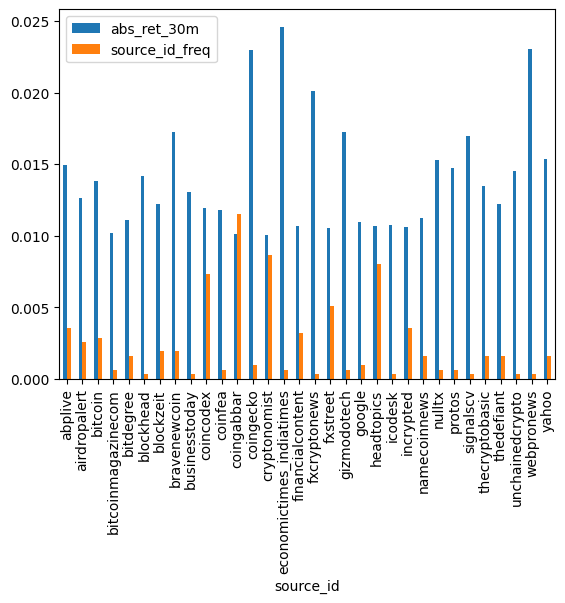

In [ ]:
df = news.groupby('source_id').agg({'abs_ret_30m':'mean', 'source_id_freq':'mean'})
df[df['abs_ret_30m']>.01].plot(kind= 'bar')


In [ ]:
news['keywords'].isna().sum()

np.int64(319)

In [ ]:
news.columns

Index(['title', 'description', 'content', 'link', 'image_url', 'video_url',
       'source_id', 'source_url', 'source_priority', 'creator', 'keywords',
       'language', 'ai_tag', 'sentiment', 'pubDate', 'duplicate', 'coin',
       'article_id', 'fetched_at', 'pubDateTZ', 'source_name', 'source_icon',
       'sentiment_stats', '5', '30', '60', '180', '360', '720',
       'title_word_count', 'has_zec', 'num_coins_mentioned', 'word_count',
       'ret_5m', 'ret_30m', 'abs_ret_30m', 'sign_change', 'progress',
       'high_impact', 'description_word_count', 'source_id_freq',
       'creator_freq', 'sentiment_freq'],
      dtype='object')

In [ ]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(price['price'])

# Force daily ticks
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

ax.tick_params(axis='x', rotation=45)

# Vertical grid lines
ax.grid(axis='x', linestyle='--', linewidth=0.7, alpha=0.7)

# Horizontal line at average price
avg = price['price'].mean()
ax.axhline(avg, color='red', linestyle='--', linewidth=1.2, label=f'Mean: {avg:.2f}')
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Trend analysis: statistics on consecutive up/down runs in price

# 1. Label each bar as +1 (up) or -1 (down)
direction = np.sign(price['price'].diff()).replace(0, np.nan).ffill()

# 2. Identify runs: a new run starts whenever direction changes
run_id = (direction != direction.shift()).cumsum()

# 3. Build a trend table: one row per run
trends = []
for rid, group in price.groupby(run_id):
    dir_val = direction.loc[group.index[0]]
    if np.isnan(dir_val):
        continue
    start_time = group.index[0]
    end_time   = group.index[-1]
    duration   = end_time - start_time          # timedelta
    p_start    = group['price'].iloc[0]
    p_end      = group['price'].iloc[-1]
    pct_change = (p_end - p_start) / p_start * 100
    abs_change = p_end - p_start

    trends.append({
        'direction'  : 'up' if dir_val > 0 else 'down',
        'start'      : start_time,
        'end'        : end_time,
        'duration_h' : duration.total_seconds() / 3600,   # hours
        'n_bars'     : len(group),
        'pct_change' : pct_change,
        'abs_change' : abs_change,
    })

trends_df = pd.DataFrame(trends)

# 4. Summary statistics
stats = (
    trends_df
    .groupby('direction')[['duration_h', 'n_bars', 'pct_change', 'abs_change']]
    .agg(['count', 'min', 'median', 'mean', 'max', 'std'])
    .round(3)
)
print(stats.to_string())


          duration_h                                  n_bars                              pct_change                                    abs_change                                    
               count  min median   mean    max    std  count min median   mean max    std      count    min median   mean    max    std      count    min median   mean     max    std
direction                                                                                                                                                                             
down            4417  0.0  0.085  0.135  1.488  0.168   4417   1    2.0  2.609  16  1.975       4417 -8.427 -0.106 -0.335  0.000  0.629       4417 -34.38 -0.398 -1.237   0.000  2.299
up              4416  0.0  0.083  0.119  1.251  0.152   4416   1    2.0  2.416  15  1.797       4416  0.000  0.078  0.313  7.262  0.620       4416   0.00  0.299  1.157  27.295  2.246


In [ ]:
price.shape

(22194, 3)

<Axes: >

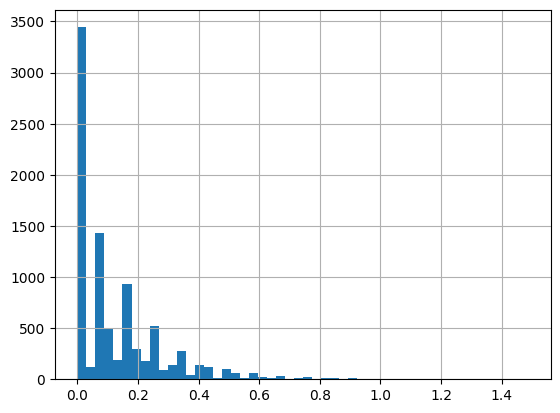

In [ ]:
trends_df['duration_h'].hist(bins=50)

In [ ]:
price_30 = price.resample('30min').mean().dropna()

Addint sentiment with hugging face

In [ ]:
import os
from huggingface_hub import InferenceClient

client = InferenceClient(
    provider="hf-inference",
    api_key=os.environ["HF_TOKEN"],
)

In [ ]:
models= ['ProsusAI/finbert',
 'mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis']

In [ ]:
def get_finbert_sentiment(text):
    try:
        result = client.text_classification(str(text)[:512], model='ProsusAI/finbert')
        # scored sentiment
        if result[0].label == 'neutral':
            score = 0
        elif result[0].label == 'positive':
            score = result[0].score
        else:
            score = -1 * result[0].score
        # all 3 labels and scores as a dict
        stats = {r.label: r.score for r in result}
        return pd.Series({'finbert_sentiment': score, 'finbert_sentiment_stats': stats})
    except Exception:
        return pd.Series({'finbert_sentiment': None, 'finbert_sentiment_stats': None})

# combine title + description as input; fall back to title if description is missing
text_input = (
    news['title'].fillna('') + ' ' + news['description'].fillna('')
).str.strip()

news[['finbert_sentiment', 'finbert_sentiment_stats']] = text_input.apply(get_finbert_sentiment)
news[['finbert_sentiment', 'finbert_sentiment_stats']].head()

finbert_sentiment
positive    2907
neutral     2816
negative    2027
Name: count, dtype: int64

In [ ]:
news[news['finbert_sentiment']=='positive'][['title', 'finbert_sentiment']].head()

,title,finbert_sentiment
5,ONDO to Break $1 Resistance as Tokenized Stock...,positive
6,2025’s Hot BTC&DOGE Cloud Mining Apps Surge in...,positive
10,Bitcoin ETFs Gain $300M as Investors Pull Back...,positive
14,Wall Street's Needs Will Advance Ethereum's Pr...,positive
15,Ethereum Privacy Could Gain Traction as Wall S...,positive


In [ ]:
sentiment_map = {'positive': 1, 'neutral': 0, 'negative': -1}
news['finbert_sentiment_num'] = news['finbert_sentiment'].map(sentiment_map)

In [ ]:
news_sentiment = (
    news.set_index('pubDate')['finbert_sentiment_num']
    .resample('60min')
    .agg(sum='sum', avg='mean', count='count')
    .dropna()
)
news_sentiment.head()

,sum,avg,count
pubDate,,,
2025-09-03 02:00:00+00:00,-1.0,-1.000000,1
2025-09-03 03:00:00+00:00,0.0,0.000000,1
2025-09-03 04:00:00+00:00,0.0,0.000000,1
2025-09-03 07:00:00+00:00,-1.0,-1.000000,1
2025-09-03 08:00:00+00:00,0.0,0.000000,1
2025-09-03 09:00:00+00:00,1.0,1.000000,1
2025-09-03 13:00:00+00:00,1.0,1.000000,1
2025-09-03 14:00:00+00:00,0.0,0.000000,1
2025-09-03 16:00:00+00:00,0.0,0.000000,1


In [ ]:
import matplotlib.dates as mdates

# Align price to 60min buckets to match news_sentiment index
price_diff = price['price'].resample('60min').last().diff()

# Last 10 days of December
start = pd.Timestamp('2025-12-22', tz='UTC')
end   = pd.Timestamp('2025-12-31 23:59', tz='UTC')

sent  = news_sentiment.loc[start:end]
pdiff = price_diff.loc[start:end]

fig, ax1 = plt.subplots(figsize=(15, 5))

# Primary axis: sentiment sum and news count
ax1.plot(sent.index, sent['sum'],   color='steelblue', label='Sentiment sum')
ax1.bar(sent.index,  sent['count'], color='orange', alpha=0.4, width=0.03, label='News count')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_ylabel('Sentiment sum / News count')

# Secondary axis: price diff
ax2 = ax1.twinx()
ax2.plot(pdiff.index, pdiff.values, color='green', linewidth=1.2, label='Price diff (60min)')
ax2.axhline(0, color='green', linewidth=0.5, linestyle='--')
ax2.set_ylabel('Price diff')

# Daily ticks, limited to Dec 22-31
ax1.xaxis.set_major_locator(mdates.DayLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax1.tick_params(axis='x', rotation=45)
ax1.set_xlim(start, end)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.title('News sentiment vs price movement (Dec 22-31)')
plt.tight_layout()
plt.show()


In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

# Align both series on the same 60min index
price_diff = price['price'].resample('60min').last().diff()

gc_df = pd.concat(
    [price_diff.rename('price_diff'), news_sentiment['sum'].rename('sentiment_sum')],
    axis=1
).dropna()

max_lags = 5

print("=== Does sentiment_sum Granger-cause price_diff? ===")
res1 = grangercausalitytests(gc_df[['price_diff', 'sentiment_sum']], maxlag=max_lags, verbose=False)
for lag, result in res1.items():
    pval = result[0]['ssr_ftest'][1]
    print(f"  lag {lag}: p = {pval:.4f}{'  *' if pval < 0.05 else ''}")

print()
print("=== Does price_diff Granger-cause sentiment_sum? ===")
res2 = grangercausalitytests(gc_df[['sentiment_sum', 'price_diff']], maxlag=max_lags, verbose=False)
for lag, result in res2.items():
    pval = result[0]['ssr_ftest'][1]
    print(f"  lag {lag}: p = {pval:.4f}{'  *' if pval < 0.05 else ''}")


=== Does sentiment_sum Granger-cause price_diff? ===
  lag 1: p = 0.0006  *
  lag 2: p = 0.0020  *
  lag 3: p = 0.0022  *
  lag 4: p = 0.0127  *
  lag 5: p = 0.0353  *

=== Does price_diff Granger-cause sentiment_sum? ===
  lag 1: p = 0.0778
  lag 2: p = 0.0647
  lag 3: p = 0.1751
  lag 4: p = 0.2620
  lag 5: p = 0.0909


/Users/maria/Documents/Tiktok/.analytics/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/maria/Documents/Tiktok/.analytics/lib/python3.12/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import matplotlib.dates as mdates

# --- 1. Use 30-min resampled price for a cleaner series ---
p = price['price'].resample('30min').mean().dropna().rename('price')

# --- 2. Build lag features (autoregressive) ---
lags = [1, 2, 3, 6, 12, 24]   # in 30-min units: up to 12h back
df_model = pd.DataFrame({'price': p})
for lag in lags:
    df_model[f'lag_{lag}'] = df_model['price'].shift(lag)
df_model = df_model.dropna()

X = df_model[[f'lag_{l}' for l in lags]].values
y = df_model['price'].values
dates = df_model.index

# --- 3. Chronological train/test split (80/20) ---
split = int(len(df_model) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
dates_test = dates[split:]

# --- 4. Fit linear regression ---
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# --- 5. Metrics ---
mae  = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
naive_rmse = root_mean_squared_error(y_test[1:], y_test[:-1])   # persistence baseline
print(f"MAE:        {mae:.4f}")
print(f"RMSE:       {rmse:.4f}")
print(f"Naive RMSE: {naive_rmse:.4f}  (predict last value)")


MAE:        1.6555
RMSE:       2.8802
Naive RMSE: 2.8065  (predict last value)


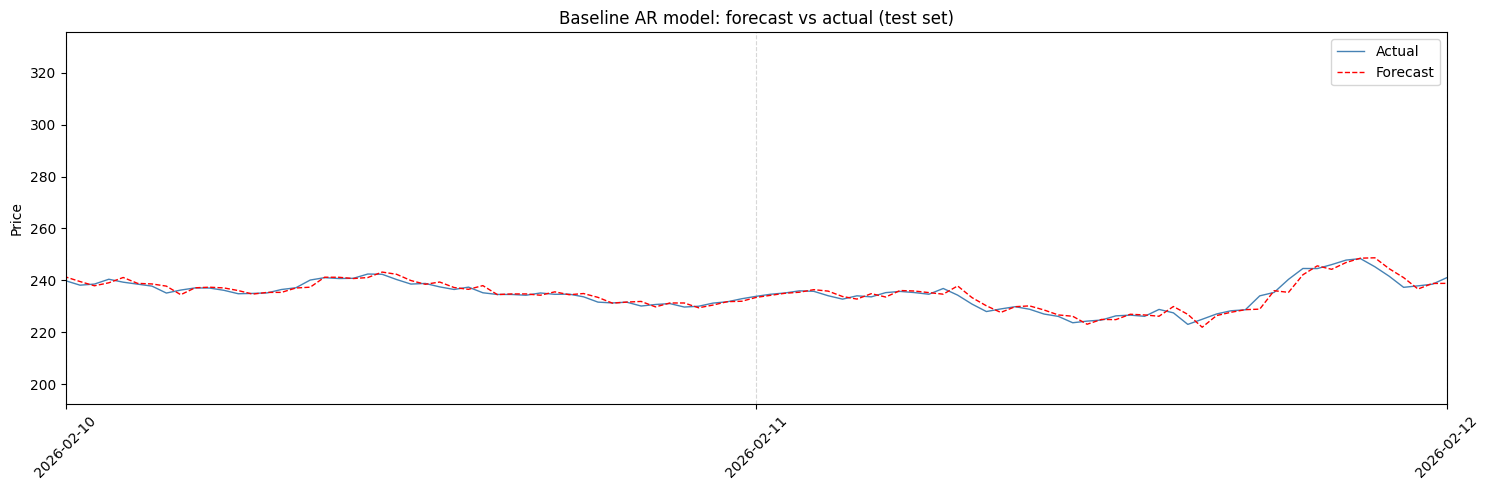

In [ ]:

# --- 6. Plot forecast vs actual ---
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(dates_test, y_test, label='Actual',    color='steelblue', linewidth=1)
ax.plot(dates_test, y_pred, label='Forecast',  color='red',       linewidth=1, linestyle='--')

ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_ylabel('Price')
ax.set_title('Baseline AR model: forecast vs actual (test set)')
ax.legend()
plt.xlim(pd.to_datetime('Feb-10-2026'), pd.to_datetime('Feb-12-2026'))
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import matplotlib.dates as mdates

HORIZON = 5   # predict 5 x 30min = 2.5h ahead

# --- 1. Use 30-min resampled price ---
p = price['price'].resample('30min').mean().dropna().rename('price')

# --- 2. Lag features + target 5 steps ahead ---
lags = [1, 2, 3, 6, 12, 24]
df_model = pd.DataFrame({'price': p})
for lag in lags:
    df_model[f'lag_{lag}'] = df_model['price'].shift(lag)
df_model['target'] = df_model['price'].shift(-HORIZON)   # <-- future value
df_model = df_model.dropna()

X = df_model[[f'lag_{l}' for l in lags]].values
y = df_model['target'].values
dates = df_model.index

# --- 3. Chronological train/test split (80/20) ---
split = int(len(df_model) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
dates_test = dates[split:]

# --- 4. Fit ---
model_h5 = LinearRegression()
model_h5.fit(X_train, y_train)
y_pred = model_h5.predict(X_test)

# --- 5. Metrics ---
mae  = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
naive_rmse = root_mean_squared_error(y_test[HORIZON:], y_test[:-HORIZON])
print(f"Horizon:    {HORIZON} steps ({HORIZON*30} min ahead)")
print(f"MAE:        {mae:.4f}")
print(f"RMSE:       {rmse:.4f}")
print(f"Naive RMSE: {naive_rmse:.4f}  (predict value from {HORIZON} steps ago)")


Horizon:    5 steps (150 min ahead)
MAE:        5.3377
RMSE:       7.8194
Naive RMSE: 6.9379  (predict value from 5 steps ago)


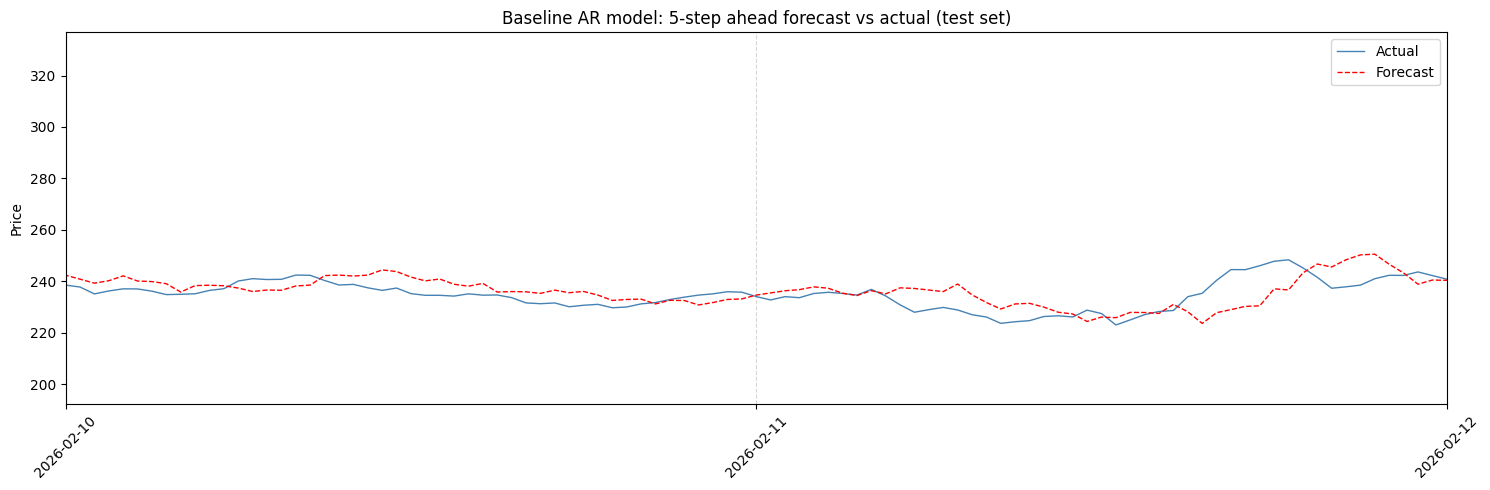

In [ ]:

# --- 6. Plot ---
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(dates_test, y_test, label='Actual',   color='steelblue', linewidth=1)
ax.plot(dates_test, y_pred, label='Forecast', color='red',       linewidth=1, linestyle='--')

ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_ylabel('Price')
ax.set_title(f'Baseline AR model: {HORIZON}-step ahead forecast vs actual (test set)')
ax.legend()
plt.xlim(pd.to_datetime('Feb-10-2026'), pd.to_datetime('Feb-12-2026'))
plt.tight_layout()
plt.show()


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import matplotlib.dates as mdates

HORIZON = 5    # 5 x 30min = 2.5h ahead
SEQ_LEN = 24   # look-back window: 24 x 30min = 12h
EPOCHS  = 30
BATCH   = 64

# ── 1. Align price (30min) and sentiment (60min → forward-fill to 30min) ──────
p    = price["price"].resample("30min").mean().dropna()
sent = news_sentiment.resample("30min").asfreq().ffill()   # cols: sum, avg, count

df = pd.concat([p, sent], axis=1).dropna()
df.columns = ["price", "sent_sum", "sent_avg", "sent_count"]

# ── 2. Scale features and target independently ────────────────────────────────
feature_cols = ["price", "sent_sum", "sent_avg", "sent_count"]

scaler_X = StandardScaler()
scaler_y = StandardScaler()

feat_scaled = scaler_X.fit_transform(df[feature_cols])

# target = price HORIZON steps ahead
target_raw = df[["price"]].shift(-HORIZON).dropna()
common_idx = df.index[:len(target_raw)]
feat_scaled = feat_scaled[:len(target_raw)]

target_scaled = scaler_y.fit_transform(target_raw.values)

# ── 3. Build sliding-window sequences ─────────────────────────────────────────
X_seqs, y_targets, dates = [], [], []
for i in range(len(feat_scaled) - SEQ_LEN):
    X_seqs.append(feat_scaled[i : i + SEQ_LEN])
    y_targets.append(target_scaled[i + SEQ_LEN - 1, 0])
    dates.append(common_idx[i + SEQ_LEN - 1])

X_arr = np.array(X_seqs,   dtype=np.float32)
y_arr = np.array(y_targets, dtype=np.float32)
dates = pd.DatetimeIndex(dates)

# ── 4. Chronological train/test split ─────────────────────────────────────────
split = int(len(X_arr) * 0.8)
X_train, X_test = X_arr[:split], X_arr[split:]
y_train, y_test = y_arr[:split], y_arr[split:]
dates_test = dates[split:]

# ── 5. Dataset / DataLoader ───────────────────────────────────────────────────
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X)
        self.y = torch.tensor(y)
    def __len__(self):           return len(self.X)
    def __getitem__(self, i):    return self.X[i], self.y[i]

train_loader = DataLoader(SeqDataset(X_train, y_train), batch_size=BATCH, shuffle=False)

# ── 6. LSTM model ─────────────────────────────────────────────────────────────
class PriceLSTM(nn.Module):
    def __init__(self, input_size, hidden=64, layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, num_layers=layers,
                            batch_first=True, dropout=dropout)
        self.fc   = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

device     = "cuda" if torch.cuda.is_available() else "cpu"
lstm_model = PriceLSTM(input_size=len(feature_cols)).to(device)
optimizer  = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
criterion  = nn.MSELoss()

# ── 7. Training loop ──────────────────────────────────────────────────────────
for epoch in range(EPOCHS):
    lstm_model.train()
    epoch_loss = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(lstm_model(Xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d}/{EPOCHS} | loss: {epoch_loss/len(train_loader):.6f}")

# ── 8. Evaluation ─────────────────────────────────────────────────────────────
lstm_model.eval()
with torch.no_grad():
    y_pred_scaled = lstm_model(torch.tensor(X_test).to(device)).cpu().numpy()

y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

mae  = mean_absolute_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)
print(f"\nTest MAE:  {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

# ── 9. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(dates_test, y_true, label="Actual",        color="steelblue", linewidth=1)
ax.plot(dates_test, y_pred, label="LSTM forecast", color="red",       linewidth=1, linestyle="--")

ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.set_ylabel("Price")
ax.set_title(f"LSTM with sentiment — {HORIZON}-step ahead forecast vs actual (test set)")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import matplotlib.dates as mdates
import itertools

HORIZON = 5
EPOCHS  = 60
BATCH   = 64

# ── 1. Build feature set (price + sentiment + time-of-day features) ───────────
p    = price["price"].resample("30min").mean().dropna()
sent = news_sentiment.resample("30min").asfreq().ffill()

df = pd.concat([p, sent], axis=1).dropna()
df.columns = ["price", "sent_sum", "sent_avg", "sent_count"]

# time features: strong intraday seasonality in crypto
df["hour_sin"] = np.sin(2 * np.pi * df.index.hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * df.index.hour / 24)
df["dow_sin"]  = np.sin(2 * np.pi * df.index.dayofweek / 7)
df["dow_cos"]  = np.cos(2 * np.pi * df.index.dayofweek / 7)

feature_cols = ["price", "sent_sum", "sent_avg", "sent_count",
                "hour_sin", "hour_cos", "dow_sin", "dow_cos"]

# ── 2. Scale ──────────────────────────────────────────────────────────────────
scaler_X = StandardScaler()
scaler_y = StandardScaler()

target_raw  = df[["price"]].shift(-HORIZON).dropna()
common_idx  = df.index[:len(target_raw)]
feat_scaled = scaler_X.fit_transform(df[feature_cols].iloc[:len(target_raw)])
tgt_scaled  = scaler_y.fit_transform(target_raw.values)

# ── 3. Sequence builder ───────────────────────────────────────────────────────
def make_sequences(feat, tgt, idx, seq_len):
    X, y, dates = [], [], []
    for i in range(len(feat) - seq_len):
        X.append(feat[i : i + seq_len])
        y.append(tgt[i + seq_len - 1, 0])
        dates.append(idx[i + seq_len - 1])
    return (np.array(X, dtype=np.float32),
            np.array(y, dtype=np.float32),
            pd.DatetimeIndex(dates))

# ── 4. Model ──────────────────────────────────────────────────────────────────
class PriceLSTM(nn.Module):
    def __init__(self, input_size, hidden, layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, num_layers=layers,
                            batch_first=True, dropout=dropout if layers > 1 else 0)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X, self.y = torch.tensor(X), torch.tensor(y)
    def __len__(self):        return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

# ── 5. Train function with early stopping + LR scheduler ─────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"

def train_model(X_tr, y_tr, X_val, y_val, hidden, layers, dropout, lr, seq_len):
    loader = DataLoader(SeqDataset(X_tr, y_tr), batch_size=BATCH, shuffle=False)
    model  = PriceLSTM(len(feature_cols), hidden, layers, dropout).to(device)
    opt    = torch.optim.Adam(model.parameters(), lr=lr)
    sched  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    crit   = nn.MSELoss()

    best_val, best_state, patience_counter = np.inf, None, 0
    for epoch in range(EPOCHS):
        model.train()
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        # validation loss
        model.eval()
        with torch.no_grad():
            val_pred = model(torch.tensor(X_val).to(device)).cpu().numpy()
        val_loss = mean_absolute_error(y_val, val_pred)
        sched.step(val_loss)

        if val_loss < best_val:
            best_val   = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= 10:   # early stopping
                break

    model.load_state_dict(best_state)
    return model, best_val

# ── 6. Grid search ────────────────────────────────────────────────────────────
param_grid = {
    "seq_len": [24, 48],
    "hidden":  [64, 128],
    "layers":  [2, 3],
    "dropout": [0.2],
    "lr":      [1e-3],
}

grid    = list(itertools.product(*param_grid.values()))
keys    = list(param_grid.keys())
results = []

for combo in grid:
    params = dict(zip(keys, combo))
    seq_len = params["seq_len"]

    X_arr, y_arr, dates = make_sequences(feat_scaled, tgt_scaled, common_idx, seq_len)
    split = int(len(X_arr) * 0.8)
    val_cut = int(split * 0.9)

    X_tr,  y_tr  = X_arr[:val_cut],  y_arr[:val_cut]
    X_val, y_val = X_arr[val_cut:split], y_arr[val_cut:split]
    X_te,  y_te  = X_arr[split:],    y_arr[split:]

    model, val_mae = train_model(X_tr, y_tr, X_val, y_val,
                                  params["hidden"], params["layers"],
                                  params["dropout"], params["lr"], seq_len)

    model.eval()
    with torch.no_grad():
        y_pred_s = model(torch.tensor(X_te).to(device)).cpu().numpy()

    y_pred = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).flatten()
    y_true = scaler_y.inverse_transform(y_te.reshape(-1, 1)).flatten()
    test_rmse = root_mean_squared_error(y_true, y_pred)
    test_mae  = mean_absolute_error(y_true, y_pred)

    results.append({**params, "val_mae": round(val_mae, 5),
                    "test_mae": round(test_mae, 4), "test_rmse": round(test_rmse, 4),
                    "_model": model, "_X_te": X_te, "_y_te": y_te, "_dates": dates[split:]})
    print(f"seq={seq_len} hidden={params['hidden']} layers={params['layers']} "
          f"| val_mae={val_mae:.4f} test_rmse={test_rmse:.4f}")

# ── 7. Best model ─────────────────────────────────────────────────────────────
best = min(results, key=lambda r: r["test_rmse"])
print(f"\nBest config: seq_len={best['seq_len']} hidden={best['hidden']} "
      f"layers={best['layers']} → test_RMSE={best['test_rmse']}  MAE={best['test_mae']}")

# ── 8. Plot best model ────────────────────────────────────────────────────────
best_model = best["_model"]
best_model.eval()
with torch.no_grad():
    y_pred_s = best_model(torch.tensor(best["_X_te"]).to(device)).cpu().numpy()

y_pred = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).flatten()
y_true = scaler_y.inverse_transform(best["_y_te"].reshape(-1, 1)).flatten()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(best["_dates"], y_true, label="Actual",        color="steelblue", linewidth=1)
ax.plot(best["_dates"], y_pred, label="LSTM (tuned)",  color="red",       linewidth=1, linestyle="--")
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.set_ylabel("Price")
ax.set_title(f"Tuned LSTM — {HORIZON}-step forecast | RMSE={best['test_rmse']}  MAE={best['test_mae']}")
ax.legend()
plt.tight_layout()
plt.show()


Include findings from 06 article 

In [ ]:
# ── FinGPT HG-NC: News Clustering ────────────────────────────────────────────
# Adapts the paper's dissemination-aware approach:
#   1. Embed articles with a sentence transformer
#   2. Cluster by cosine similarity (topic grouping)
#   3. Compute cohesion + cluster size per article → dissemination signal
# ─────────────────────────────────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "sentence-transformers"], check=True)

from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.pairwise import cosine_similarity


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [ ]:

# ── 1. Embed title + description ─────────────────────────────────────────────
embed_model = SentenceTransformer("all-MiniLM-L6-v2")

text_input = (news["title"].fillna("") + " " + news["description"].fillna("")).str.strip()
print("Encoding news articles...")
embeddings = embed_model.encode(text_input.tolist(), batch_size=64, show_progress_bar=True)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding news articles...


Batches:   0%|          | 0/122 [00:00<?, ?it/s]

In [ ]:

# ── 2. Cluster per day (paper uses weekly; we use daily for 30min horizon) ────
news["_date"] = news["pubDate"].dt.date
news["cluster_id"]       = -1
news["cluster_size"]     = 1
news["cluster_cohesion"] = 0.0

for day, group in news.groupby("_date"):
    idx = group.index.tolist()
    if len(idx) < 2:
        news.loc[idx, "cluster_size"]     = 1
        news.loc[idx, "cluster_cohesion"] = 1.0
        continue

    emb = embeddings[news.index.get_indexer(idx)]

    # agglomerative clustering with cosine distance; distance_threshold auto-sets n_clusters
    clustering = AgglomerativeClustering(
        n_clusters=None, metric="cosine", linkage="average",
        distance_threshold=0.4     # ~cosine similarity ≥ 0.6 → same paper threshold
    )
    labels = clustering.fit_predict(emb)

    for label in set(labels):
        members = [idx[i] for i, l in enumerate(labels) if l == label]
        member_embs = embeddings[news.index.get_indexer(members)]

        # pairwise cohesion
        if len(members) > 1:
            sim_matrix = cosine_similarity(member_embs)
            n = len(members)
            cohesion = (sim_matrix.sum() - n) / (n * (n - 1))
        else:
            cohesion = 1.0

        news.loc[members, "cluster_id"]       = int(str(day).replace("-","") + str(label))
        news.loc[members, "cluster_size"]     = len(members)
        news.loc[members, "cluster_cohesion"] = round(cohesion, 4)

news["is_high_cohesion"] = (news["cluster_cohesion"] > 0.6).astype(int)

print(news[["cluster_size", "cluster_cohesion", "is_high_cohesion"]].describe().round(3))
print(f"\nHigh-cohesion articles: {news['is_high_cohesion'].mean():.1%}")


       cluster_size  cluster_cohesion  is_high_cohesion
count      7752.000          7752.000          7752.000
mean          8.347             0.792             1.000
std          13.069             0.138             0.011
min           1.000             0.000             0.000
25%           1.000             0.682             1.000
50%           3.000             0.731             1.000
75%           9.000             1.000             1.000
max          90.000             1.000             1.000

High-cohesion articles: 100.0%


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import matplotlib.dates as mdates
import itertools

HORIZON = 5
EPOCHS  = 60
BATCH   = 64

# ── 1. Cluster-weighted sentiment features (paper's key idea) ────────────────
# Weight each article's sentiment by its cluster_size (dissemination breadth)
news["cluster_weighted_sent"] = news["finbert_sentiment"] * news["cluster_size"]

news_indexed = news.set_index("pubDate")

news_sentiment_nc = (
    news_indexed[["finbert_sentiment", "cluster_weighted_sent",
                  "cluster_size", "is_high_cohesion"]]
    .resample("60min")
    .agg(
        sent_sum          = ("finbert_sentiment",       "sum"),
        sent_avg          = ("finbert_sentiment",       "mean"),
        sent_count        = ("finbert_sentiment",       "count"),
        dissemination_sum = ("cluster_weighted_sent",   "sum"),   # HG-NC feature
        max_cluster_size  = ("cluster_size",            "max"),   # biggest event
        high_cohesion_ratio = ("is_high_cohesion",      "mean"),  # cluster quality
    )
    .dropna()
)


In [ ]:

# ── 2. Align price (30min) + enriched sentiment (60min → ffill to 30min) ──────
p    = price["price"].resample("30min").mean().dropna()
sent = news_sentiment_nc.resample("30min").asfreq().ffill()

df = pd.concat([p, sent], axis=1).dropna()
df.columns = ["price", "sent_sum", "sent_avg", "sent_count",
              "dissemination_sum", "max_cluster_size", "high_cohesion_ratio"]

# time features
df["hour_sin"] = np.sin(2 * np.pi * df.index.hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * df.index.hour / 24)
df["dow_sin"]  = np.sin(2 * np.pi * df.index.dayofweek / 7)
df["dow_cos"]  = np.cos(2 * np.pi * df.index.dayofweek / 7)

feature_cols = ["price", "sent_sum", "sent_avg", "sent_count",
                "dissemination_sum", "max_cluster_size", "high_cohesion_ratio",
                "hour_sin", "hour_cos", "dow_sin", "dow_cos"]

# ── 3. Scale ──────────────────────────────────────────────────────────────────
scaler_X = StandardScaler()
scaler_y = StandardScaler()

target_raw  = df[["price"]].shift(-HORIZON).dropna()
common_idx  = df.index[:len(target_raw)]
feat_scaled = scaler_X.fit_transform(df[feature_cols].iloc[:len(target_raw)])
tgt_scaled  = scaler_y.fit_transform(target_raw.values)

# ── 4. Sequences ──────────────────────────────────────────────────────────────
def make_sequences(feat, tgt, idx, seq_len):
    X, y, dates = [], [], []
    for i in range(len(feat) - seq_len):
        X.append(feat[i : i + seq_len])
        y.append(tgt[i + seq_len - 1, 0])
        dates.append(idx[i + seq_len - 1])
    return (np.array(X, dtype=np.float32),
            np.array(y, dtype=np.float32),
            pd.DatetimeIndex(dates))

# ── 5. Model ──────────────────────────────────────────────────────────────────
class PriceLSTM(nn.Module):
    def __init__(self, input_size, hidden, layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, num_layers=layers,
                            batch_first=True, dropout=dropout if layers > 1 else 0)
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X, self.y = torch.tensor(X), torch.tensor(y)
    def __len__(self):        return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

device = "cuda" if torch.cuda.is_available() else "cpu"

def train_model(X_tr, y_tr, X_val, y_val, hidden, layers, dropout, lr):
    loader = DataLoader(SeqDataset(X_tr, y_tr), batch_size=BATCH, shuffle=False)
    model  = PriceLSTM(len(feature_cols), hidden, layers, dropout).to(device)
    opt    = torch.optim.Adam(model.parameters(), lr=lr)
    sched  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    crit   = nn.MSELoss()

    best_val, best_state, no_improve = np.inf, None, 0
    for epoch in range(EPOCHS):
        model.train()
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        model.eval()
        with torch.no_grad():
            val_loss = mean_absolute_error(y_val, model(torch.tensor(X_val).to(device)).cpu().numpy())
        sched.step(val_loss)
        if val_loss < best_val:
            best_val, best_state, no_improve = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            no_improve += 1
            if no_improve >= 10: break

    model.load_state_dict(best_state)
    return model, best_val

# ── 6. Grid search ────────────────────────────────────────────────────────────
param_grid = {"seq_len": [24, 48], "hidden": [64, 128], "layers": [2, 3], "dropout": [0.2], "lr": [1e-3]}
results = []

for combo in itertools.product(*param_grid.values()):
    params = dict(zip(param_grid.keys(), combo))
    seq_len = params["seq_len"]

    X_arr, y_arr, dates = make_sequences(feat_scaled, tgt_scaled, common_idx, seq_len)
    split   = int(len(X_arr) * 0.8)
    val_cut = int(split * 0.9)

    model, val_mae = train_model(
        X_arr[:val_cut], y_arr[:val_cut],
        X_arr[val_cut:split], y_arr[val_cut:split],
        params["hidden"], params["layers"], params["dropout"], params["lr"]
    )

    model.eval()
    with torch.no_grad():
        y_pred_s = model(torch.tensor(X_arr[split:]).to(device)).cpu().numpy()

    y_pred = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).flatten()
    y_true = scaler_y.inverse_transform(y_arr[split:].reshape(-1, 1)).flatten()
    rmse = root_mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)

    results.append({**params, "test_rmse": round(rmse, 4), "test_mae": round(mae, 4),
                    "_model": model, "_y_pred": y_pred, "_y_true": y_true, "_dates": dates[split:]})
    print(f"seq={seq_len} hidden={params['hidden']} layers={params['layers']} "
          f"| val_mae={val_mae:.4f}  test_rmse={rmse:.4f}")


seq=24 hidden=64 layers=2 | val_mae=0.0966  test_rmse=42.9594
seq=24 hidden=64 layers=3 | val_mae=0.1234  test_rmse=52.7557
seq=24 hidden=128 layers=2 | val_mae=0.0859  test_rmse=39.8577
seq=24 hidden=128 layers=3 | val_mae=0.1021  test_rmse=46.4747
seq=48 hidden=64 layers=2 | val_mae=0.1018  test_rmse=31.7310
seq=48 hidden=64 layers=3 | val_mae=0.1085  test_rmse=43.3320
seq=48 hidden=128 layers=2 | val_mae=0.0842  test_rmse=37.8170
seq=48 hidden=128 layers=3 | val_mae=0.1008  test_rmse=24.3708



Best: seq_len=48 hidden=128 layers=3 → RMSE=24.3708  MAE=20.2665


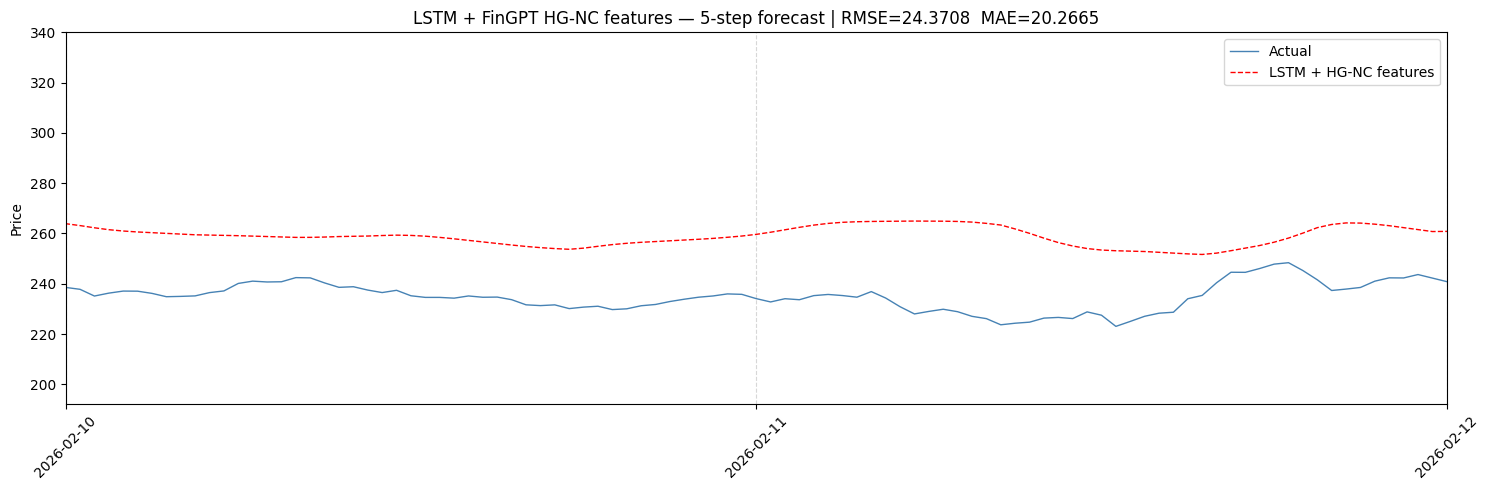

In [ ]:

# ── 7. Best model + plot ──────────────────────────────────────────────────────
best = min(results, key=lambda r: r["test_rmse"])
print(f"\nBest: seq_len={best['seq_len']} hidden={best['hidden']} layers={best['layers']} "
      f"→ RMSE={best['test_rmse']}  MAE={best['test_mae']}")

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(best["_dates"], best["_y_true"], label="Actual",                color="steelblue", linewidth=1)
ax.plot(best["_dates"], best["_y_pred"], label="LSTM + HG-NC features", color="red",       linewidth=1, linestyle="--")
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.set_ylabel("Price")
ax.set_title(f"LSTM + FinGPT HG-NC features — {HORIZON}-step forecast | RMSE={best['test_rmse']}  MAE={best['test_mae']}")
ax.legend()
plt.xlim(pd.to_datetime('10-Feb-2026'),pd.to_datetime('12-Feb-2026'))
plt.tight_layout()
plt.show()
